# Tarea 1

## Objetivo:

Implementar y contrastar dos modelos de clasificación —uno explicativo y otro predictivo— bajo criterios de rigor técnico y buenas prácticas de Data Mining y Modelización Predictiva.

### Sub-objetivos:
- Diferenciar y contrastar el enfoque de un modelo explicativo frente a uno predictivo en problemas de clasificación.
- Identificar y extraer los patrones clave de las features que determinan el comportamiento de la variable target.
- Optimizar el rendimiento predictivo mediante transformaciones de las features.
- Desarrollar un código limpio y estructurado, aplicando un manejo de errores eficiente para asegurar que el pipeline de datos no se rompa.
- Utilizar de forma autónoma la documentación de _scikit-learn_ y _statsmodels_ para implementar los algoritmos y resolver dudas técnicas.

## Tarea del estudiante:

Lee detenidamente las siguientes instrucciones.

El estudiante tendrá bastante libertad para realizar la tarea, utilizando sus propios criterios y estrategias. No obstante,

- deberá estar limitado a las librerías de _pandas_, _numpy_, _scikit-learn_ y _statsmodels_;
- no modificará los comentarios de los enunciados, pero sí podrá editar y crear celdas para completar cada una de las partes;
- en los apartados que se solicita "explicación" o "comentario", no olvidar dejar vuestra reflexión, si no estuviese, no se puntuaría ese apartado.

Una vez finalizada la actividad, guarda tu fichero, reinicia el kernel vuélvelo a ejecutar. No deben aparecer errores. Un notebook con errores es una Tarea incompleta. Para la entrega, TODO EL CÓDIGO DEBE ESTAR EJECUTADO (EN ORDEN) EN EL FICHERO QUE ENTREGÁIS.

RECUERDA SUBIR CADA UNO DE LOS FICHEROS .ipynb TAL CUAL (sueltos), SIN COMPRIMIR Y SIN CAMBIARLES EL NOMBRE. Los ficheros subidos deben tener exactamente el mismo nombre de fichero que tenían cuando los recibiste. No subas ningún PDF ni ningún fichero ZIP ni nada similar. La plataforma ya los separa automáticamente en carpetas que traen el nombre y apellidos del alumno, por lo que NO es necesario que lo pongas en ninguna parte.

## Evaluación:

- Este notebook se evalúa sobre 10 puntos.

# Parte 0: Librerías

In [1]:
# Se reserva este espacio para la importación de librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

pd.set_option('display.max_columns', None)
sns.set_style("darkgrid")

seed = 99

# el estudiante puede añadir aquí las librerías que necesite

# Parte 0: Dataset

Los dos trabajos solitados se harán con el siguiente dataset de "Cancelación de reservas de hotel". Cada registro supone una reserva que ha sido cancelada o disfrutada por parte de clientes. A continuación, se da más detalle sobre las columnas:

**target**:
- *reserva_cancelada*: Indica si la reserva fue cancelada (1) o no cancelada (0).

**features**:
- *dias_antelacion*: Número de días que transcurren entre la fecha en la que el cliente hace la reserva y la fecha de su llegada al hotel.
- *fecha_llegada*: Fecha de comienzo de la reserva.
- *noches_estancia*: Noches totales de la reserva.
- *estado_reserva*: Estado final de la reserva. Valores: Canceled (el cliente canceló), Check-Out (el cliente disfrutó la reserva), No-Show (el cliente nunca apareció ni avisó).
- *fecha_estado_reserva*: Fecha de registro de la variable estado_reserva.
- *adultos*: Número de adultos incluidos en la reserva.
- *ninos*: Número de niños.
- *bebes*: Número de bebés.
- *regimen_alimenticio*: Régimen alimenticio contratado (BB: Solo desayuno, HB: Media pensión, FB: Pensión completa, SC/Undefined: Sin comidas).
- *tipo_habitacion_reservada*: Tipo de habitación que el cliente solicitó originalmente (codificado por letras: A, B, C...).
- *tipo_habitacion_asignada*: Tipo de habitación que el hotel le asignó finalmente en el momento del check-in.
- *plazas_parking_requeridas*: Número de plazas de parking que solicita el cliente.
- *peticiones_especiales_totales*: Número de peticiones especiales realizadas (ej. cuna, cama extra, piso alto).
- *pais_origen*: País de origen del cliente (en formato de código internacional de tres letras, ej. PRT, ESP, FRA).
- *segmento_mercado*: Segmento de mercado al que pertenece la reserva (ej. Directo, Grupos, Agencias de viaje corporativas, etc.).
- *canal_distribucion*: Canal por el que llegó la reserva al hotel (ej. TA/TO: Agencias/Operadores, Directo, GDS, etc.).
- *cliente_repetido*: Variable binaria (0 o 1). Indica si el cliente ya se ha alojado en este hotel en el pasado.
- *cancelaciones_previas*: Número de reservas que este cliente ha cancelado en el pasado antes de la reserva actual.
- *reservas_previas_no_canceladas*: Número de reservas anteriores que el cliente realizó y sí completó con éxito (no canceló).
- *tipo_deposito*: Indica si el cliente realizó un depósito para asegurar la reserva (No Deposit, Non Refundable [no reembolsable], Refundable [reembolsable]).
- *cambios_reserva*: Número de modificaciones o cambios hechos a la reserva desde que se creó hasta el día de la llegada.
- *dias_lista_espera*: Número de días que la reserva estuvo retenida en lista de espera antes de ser confirmada.
- *tipo_cliente*: Tipo de cliente/reserva (Transient: Particular suelto, Group: Grupo, Contract: Tarifa corporativa recurrente, Transient-Party: Particular ligado a grupo).
- *precio_medio_diario*: Precio medio diario (Average Daily Rate) que paga el cliente por noche de habitación.

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/eduardofc/data/refs/heads/main/reservas_hotel.csv")
df.head()

,reserva_cancelada,dias_antelacion,adultos,ninos,bebes,regimen_alimenticio,pais_origen,segmento_mercado,canal_distribucion,cliente_repetido,cancelaciones_previas,reservas_previas_no_canceladas,tipo_habitacion_reservada,tipo_habitacion_asignada,cambios_reserva,tipo_deposito,dias_lista_espera,tipo_cliente,precio_medio_diario,plazas_parking_requeridas,peticiones_especiales_totales,estado_reserva,fecha_estado_reserva,fecha_llegada,noches_estancia
0,0,342,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-06,0
1,0,737,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-06,0
2,0,7,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-06,1
3,0,13,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-06,1
4,0,14,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,98.0,0,1,Check-Out,2015-07-03,2015-07-06,2


In [3]:
df.shape

(119390, 25)

In [4]:
# Todo el trabajo del estudiante se realizará con df1.
# Mantendremos la variable df para comparar cuando sea necesario.

df1 = df.copy()

# Parte 1: Tratamiento previo del dataset (EDA + Feature Engineering)

## Variables de fecha (2 puntos)
En este apartado se pide identificar las variables de fecha y crear nuevas features que puedan ser de interés para encontrar "patrones" de cancelación.

Para ello, se pide trabajar **exclusivamente** las columnas de fecha. Al final de cada celda, se eliminará la columna de fecha y se pondrá un comentario por cada una de las **nuevas features** que se hayan creado explicando qué significa. Tenéis total libertad para abordarlo según vuestro propio criterio y considerar la estrategia que mejor convenga.

<div class="alert alert-block alert-danger">
<b>Importante:</b> Máxima atención a "data leakage", utilizar información del "futuro" o datos a los que no tendría acceso en el mundo real para construir modelos predictivos o explicativos puede invalidar totalmente cualquier trabajo. En concreto, si usamos data leakage, esta tarea se puntuará con 0.0. 
</div>

In [5]:
# Código del estudiante

df1["fecha_llegada"] = pd.to_datetime(df1["fecha_llegada"], errors="coerce")
df1["mes_llegada"] = df1["fecha_llegada"].dt.month
df1["dia_semana_llegada"] = df1["fecha_llegada"].dt.dayofweek

# Eliminación de las columnas de fecha
df1.drop(columns=["fecha_estado_reserva", "fecha_llegada"], inplace=True)

In [6]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   reserva_cancelada               119390 non-null  int64  
 1   dias_antelacion                 119390 non-null  int64  
 2   adultos                         119390 non-null  int64  
 3   ninos                           119386 non-null  float64
 4   bebes                           119390 non-null  int64  
 5   regimen_alimenticio             119390 non-null  str    
 6   pais_origen                     118902 non-null  str    
 7   segmento_mercado                119390 non-null  str    
 8   canal_distribucion              119390 non-null  str    
 9   cliente_repetido                119390 non-null  int64  
 10  cancelaciones_previas           119390 non-null  int64  
 11  reservas_previas_no_canceladas  119390 non-null  int64  
 12  tipo_habitacion_reservada  

In [7]:
# Explicación de las nuevas columnas creadas

#mes_llegada: extraemos el mes de llegada para detectar posibles patrones estacionales en las cancelaciones.
   #Por ejemplo, puede existir un comportamiento diferente entre reservas realizadas para temporada alta (verano) y temporada baja.


#dia_semana_llegada: extraemos el día de la semana de llegada para identificar diferencias entre tipos de viaje,
      #como posibles estancias de ocio durante fines de semana frente a estancias entre semana.

## Data split (0 puntos)

En este apartado se pide separar el dataset original en train/test, dando un 20% de los datos al conjunto de test (recordad usar semilla).

<div class="alert alert-block alert-danger">
<b>Importante:</b> Máxima atención a "data leakage", utilizar información del conjunto de test para ajustar el modelo o realizar ajustes con el conjunto de test (los _.fit()_) supone un error grave a la hora de analizar los datos y ajustar los modelos. En concreto, si usamos data leakage, esta tarea se puntuará con 0.0. 
</div>

In [8]:
# Código del estudiante

from sklearn.model_selection import train_test_split

target = "reserva_cancelada"
X = df1.drop(columns=[target, "estado_reserva"])
y = df1[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=seed)

## Imputación de nulos (0 puntos)

No podremos avanzar demasiado si seguimos teniendo nulos. Por ello, se pide detectar los nulos en el dataset y tomar una decisión sobre las actuaciones que llevéis a cabo. Tenéis total libertad para abordarlo según vuestro propio criterio y considerar la estrategia que mejor convenga.

In [9]:
# Código del estudiante
df_aux_train = pd.DataFrame(X_train.isna().sum(), columns=["n_nulls"])
df_aux_train.sort_values('n_nulls', ascending=False).head(20)

,n_nulls
pais_origen,396
ninos,2
dias_antelacion,0
cambios_reserva,0
mes_llegada,0
noches_estancia,0
peticiones_especiales_totales,0
plazas_parking_requeridas,0
precio_medio_diario,0
tipo_cliente,0


In [10]:
df_aux_test = pd.DataFrame(X_test.isna().sum(), columns=["n_nulls"])
df_aux_test.sort_values('n_nulls', ascending=False).head(20)

,n_nulls
pais_origen,92
ninos,2
dias_antelacion,0
cambios_reserva,0
mes_llegada,0
noches_estancia,0
peticiones_especiales_totales,0
plazas_parking_requeridas,0
precio_medio_diario,0
tipo_cliente,0


In [11]:
X_train["ninos"] = X_train["ninos"].fillna(0)
X_train["pais_origen"] = X_train["pais_origen"].fillna("Unknown")
print(X_train.isna().sum())

dias_antelacion                   0
adultos                           0
ninos                             0
bebes                             0
regimen_alimenticio               0
pais_origen                       0
segmento_mercado                  0
canal_distribucion                0
cliente_repetido                  0
cancelaciones_previas             0
reservas_previas_no_canceladas    0
tipo_habitacion_reservada         0
tipo_habitacion_asignada          0
cambios_reserva                   0
tipo_deposito                     0
dias_lista_espera                 0
tipo_cliente                      0
precio_medio_diario               0
plazas_parking_requeridas         0
peticiones_especiales_totales     0
noches_estancia                   0
mes_llegada                       0
dia_semana_llegada                0
dtype: int64


In [12]:
X_test["ninos"] = X_test["ninos"].fillna(0)
X_test["pais_origen"] = X_test["pais_origen"].fillna("Unknown")
print(X_test.isna().sum())

dias_antelacion                   0
adultos                           0
ninos                             0
bebes                             0
regimen_alimenticio               0
pais_origen                       0
segmento_mercado                  0
canal_distribucion                0
cliente_repetido                  0
cancelaciones_previas             0
reservas_previas_no_canceladas    0
tipo_habitacion_reservada         0
tipo_habitacion_asignada          0
cambios_reserva                   0
tipo_deposito                     0
dias_lista_espera                 0
tipo_cliente                      0
precio_medio_diario               0
plazas_parking_requeridas         0
peticiones_especiales_totales     0
noches_estancia                   0
mes_llegada                       0
dia_semana_llegada                0
dtype: int64


In [13]:

# Se detectaron valores nulos en las variables ninos y pais_origen

# La variable ninos se imputó con el valor 0 debido a la ausencia de información se interpreta como que la reserva no incluye niños

# La variable pais_origen se imputó con la categoría "Unknown", ya que no se dispone de información 
   #sobre el país del cliente y se conserva la información de la reserva sin eliminar registros

## Exploración de features y creación de nuevas features (1 punto)

En este apartado se pide explorar con plots todas las features

In [14]:
# Código del estudiante (opcional)


num_cols = ["dias_antelacion", "adultos", "ninos", "bebes", "cancelaciones_previas", "reservas_previas_no_canceladas", "cambios_reserva",
            "dias_lista_espera", "precio_medio_diario","plazas_parking_requeridas","peticiones_especiales_totales", "noches_estancia"]

cat_cols = ["regimen_alimenticio", "pais_origen", "segmento_mercado", "canal_distribucion","tipo_habitacion_reservada",
            "tipo_habitacion_asignada", "tipo_cliente", "cliente_repetido", "mes_llegada", "dia_semana_llegada"]

ord_cols = ["tipo_deposito"]


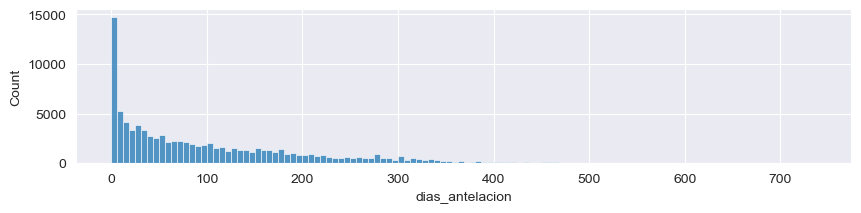

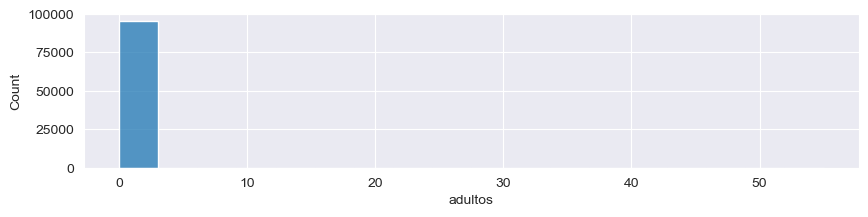

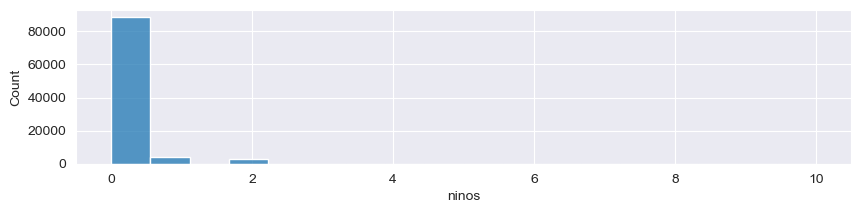

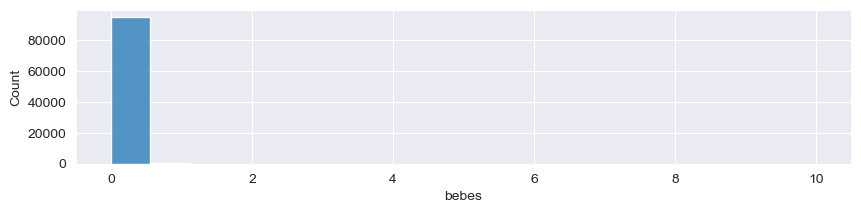

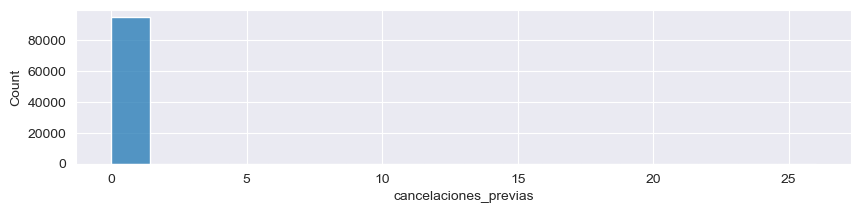

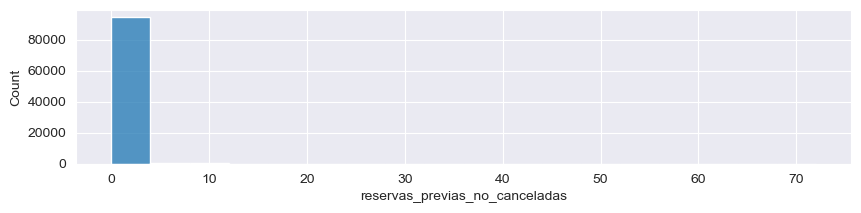

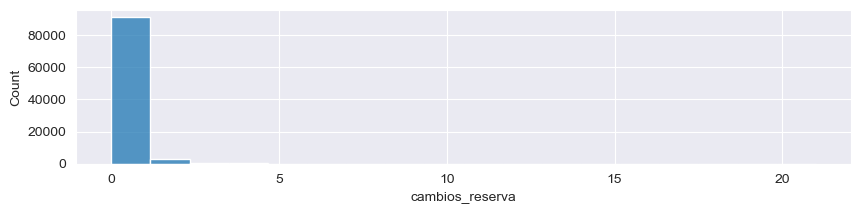

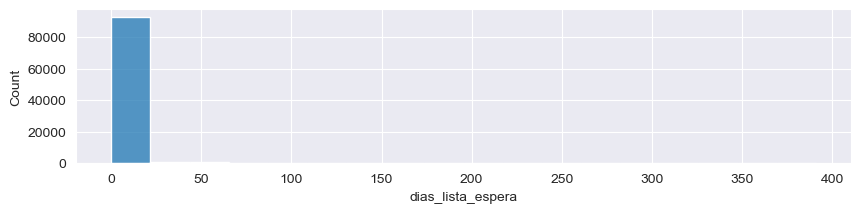

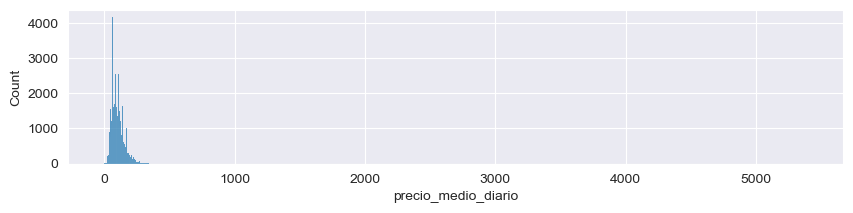

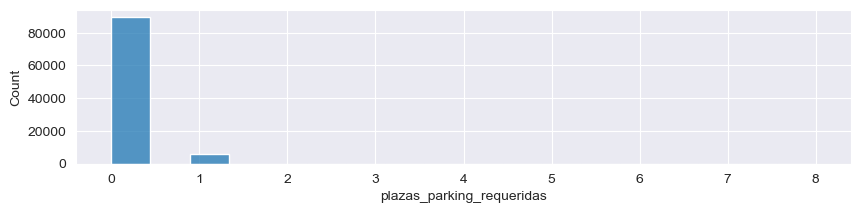

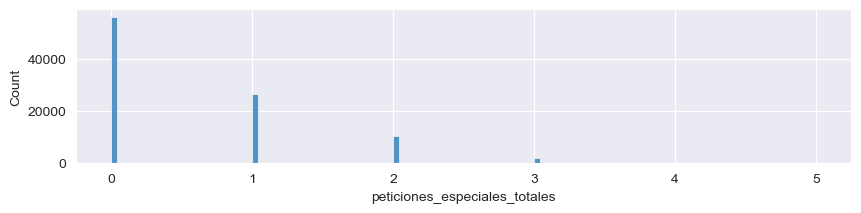

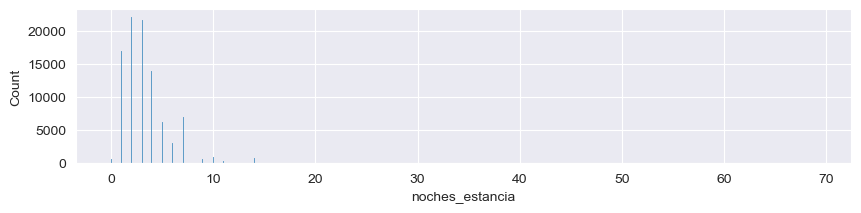

In [15]:
# Código del estudiante
# Numéricas

for col in num_cols:
    plt.figure(figsize=(10,2))
    sns.histplot(data=X_train, x=col)
    plt.show()


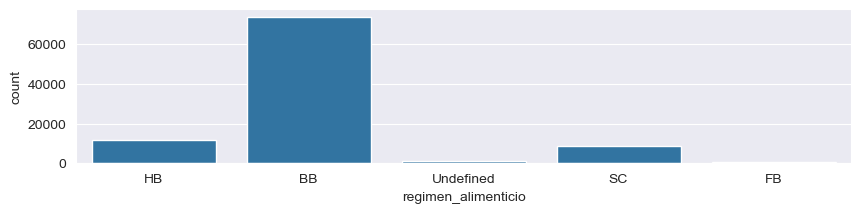

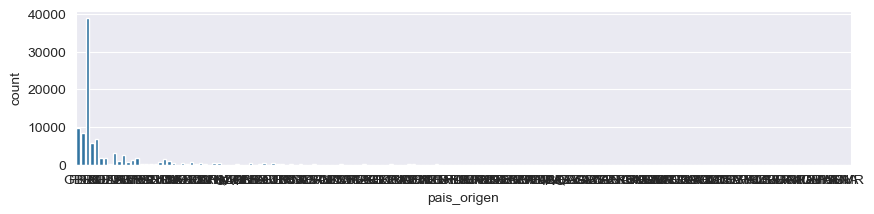

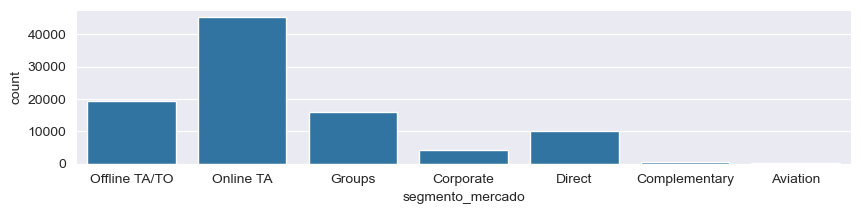

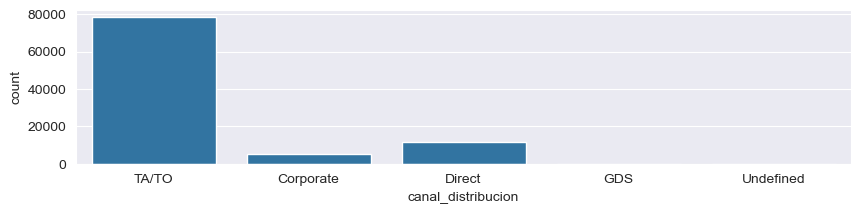

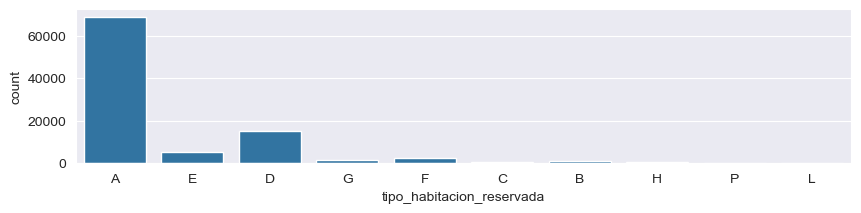

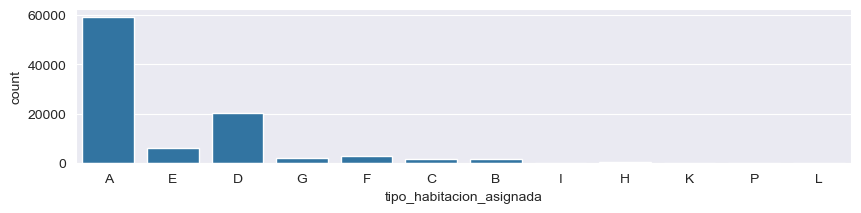

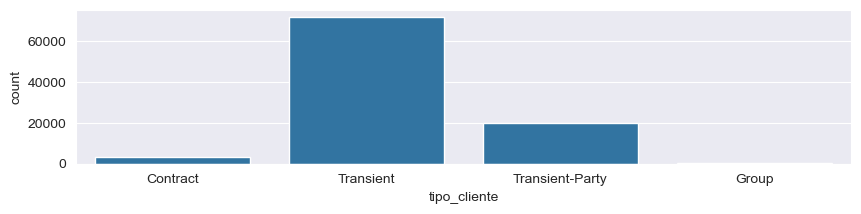

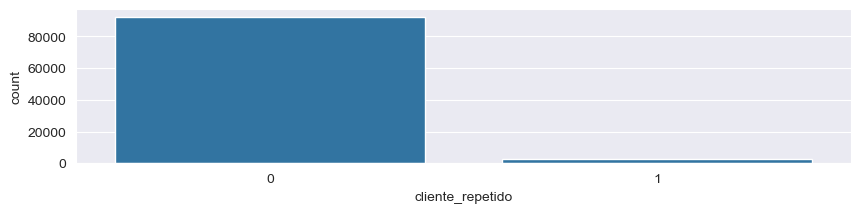

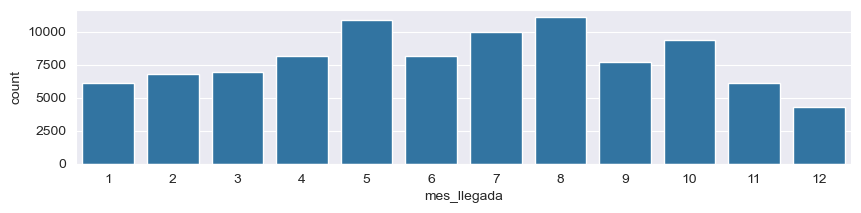

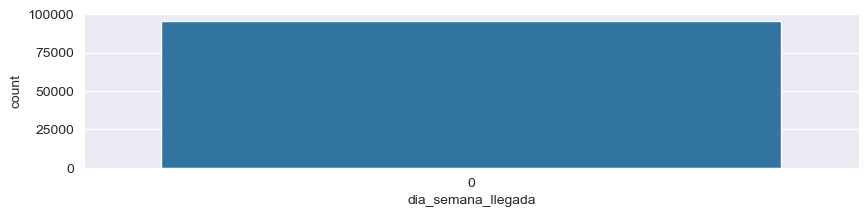

In [16]:
#Categóricas 

for col in cat_cols:
    plt.figure(figsize=(10,2))
    sns.countplot(data=X_train, x=col)
    plt.show()

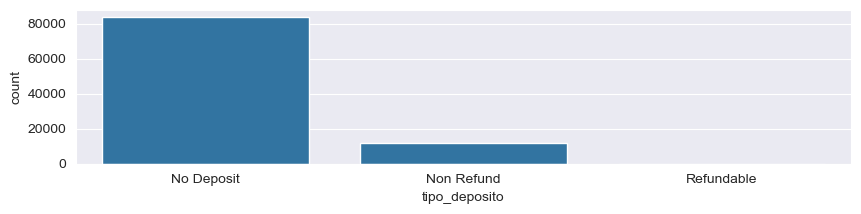

In [17]:
#Ordinales

for col in ord_cols:
    plt.figure(figsize=(10,2))
    sns.countplot(data=X_train, x=col)
    plt.show()

A continuación, si consideráis que hay que transformar features, puede hacerlo en este apartado. Tenéis total libertad para abordarlo según vuestro propio criterio y considerar la estrategia que mejor convenga (OneHotEncoder, LabelEncoder, PowerTransformer, KBinDiscretizer, etc). Tenéis total libertad para abordarlo según vuestro propio criterio y considerar la estrategia que mejor convenga, incluida cualquier otra funcion de _scikit-learn_ o cualquier transformación customizada acorde a vuestro criterio.

<div class="alert alert-block alert-warning">
<b>Importante:</b> Cuidado con las transformaciones, puede que no interese hacer las mismas transformaciones para un modelo "explicativo" que para uno "predictivo". En este apartado, se recomienda hacer <b>solo</b> las transformaciones que sean útiles para ambos tipos de trabajo. 
</div>

In [18]:
# Código del estudiante

#Numéricas 
X_train["total_personas"] = X_train["adultos"] + X_train["ninos"] + X_train["bebes"]
X_test["total_personas"] = X_test["adultos"] + X_test["ninos"] + X_test["bebes"]

X_train["precio_total"] = X_train["precio_medio_diario"] * X_train["noches_estancia"]
X_test["precio_total"] = X_test["precio_medio_diario"] * X_test["noches_estancia"]

X_train["es_familia"] = ((X_train["ninos"] + X_train["bebes"]) > 0).astype(int)
X_test["es_familia"] = ((X_test["ninos"] + X_test["bebes"]) > 0).astype(int)

X_train["tiene_peticion_especial"] = (X_train["peticiones_especiales_totales"] > 0).astype(int)
X_test["tiene_peticion_especial"] = (X_test["peticiones_especiales_totales"] > 0).astype(int)


In [19]:


num_cols1 = [ "dias_antelacion", "precio_medio_diario", "cancelaciones_previas", "reservas_previas_no_canceladas",
    "dias_lista_espera", "precio_total"]


In [20]:
# Numéricas

from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson")

pt.fit(X_train[num_cols1])

X_train[num_cols1] = pt.transform(X_train[num_cols1])
X_test[num_cols1] = pt.transform(X_test[num_cols1])



In [21]:

# Creación de nuevas features:
# Se generan nuevas variables para aportar información adicional al modelo, como el número
# total de personas, el precio total de la estancia, si es una reserva familiar y si tiene peticiones especiales.

# Transformación numérica:
# Se aplica PowerTransformer a las variables con mayor asimetría para reducir el efecto de valores extremos. 

# Variables no transformadas:
# Las variables numéricas discretas con pocos valores se mantienen sin modificar para conservar su interpretación.


In [22]:
# Categóricas
for col in cat_cols:
    print(col, X_train[col].nunique())

regimen_alimenticio 5
pais_origen 171
segmento_mercado 7
canal_distribucion 5
tipo_habitacion_reservada 10
tipo_habitacion_asignada 12
tipo_cliente 4
cliente_repetido 2
mes_llegada 12
dia_semana_llegada 1


In [23]:
# Categóricas

from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False, min_frequency=0.02)

ohe.fit(X_train[cat_cols])

X_train_ohe = ohe.transform(X_train[cat_cols])
X_test_ohe = ohe.transform(X_test[cat_cols])

new_cols = ohe.get_feature_names_out(cat_cols)

X_train_ohe = pd.DataFrame(X_train_ohe, columns=new_cols, index=X_train.index)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=new_cols, index=X_test.index)

X_train = pd.concat([X_train.drop(columns=cat_cols), X_train_ohe], axis=1)
X_test = pd.concat([X_test.drop(columns=cat_cols), X_test_ohe], axis=1)



In [24]:
# Categóricas

# One-Hot Encoder:
# Las variables categóricas nominales se transforman en variables binarias para que puedan
# Incluimos min_frequency ya se observa que muchas columnas nuevas tras el One Hot Encoding muestran frecuencias de 1 cercanas a cero
# para ello introducimos el min_frequency para agrupar automáticamente las categorías raras en una columna común de "Otros"

In [25]:
# Ordinales
from sklearn.preprocessing import OrdinalEncoder

orden_deposito = [["No Deposit", "Refundable", "Non Refund"]]
oe = OrdinalEncoder(categories=orden_deposito, handle_unknown="use_encoded_value", unknown_value=-1)
X_train_ord = oe.fit_transform(X_train[["tipo_deposito"]])
X_test_ord = oe.transform(X_test[["tipo_deposito"]])

X_train_ord = pd.DataFrame(X_train_ord, columns=["tipo_deposito"], index=X_train.index)
X_test_ord = pd.DataFrame(X_test_ord, columns=["tipo_deposito"], index=X_test.index)


X_train = pd.concat([X_train.drop(columns=["tipo_deposito"]), X_train_ord], axis=1)
X_test = pd.concat([X_test.drop(columns=["tipo_deposito"]), X_test_ord], axis=1)


In [26]:
# La variable 'tipo_deposito' se ha codificado mediante OrdinalEncoder al tratarse de
# una variable categórica ordinal. 
# Se ha definido un orden lógico entre sus categorías (No Deposit < Refundable < Non Refundable), sustituyéndolas por valores numéricos


Finalmente, se os pedirá realizar otra vez los plots de todas las features (se asume que se han modificado algunas, en caso contrario no sería necesario trabajar la siguiente celda).

In [27]:
# Código del estudiante (opcional)

cat_cols = ...
ord_cols = ...
num_cols = ...

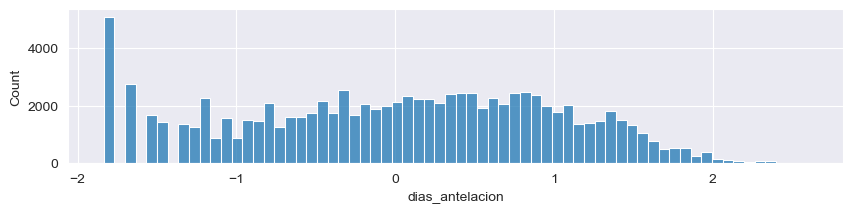

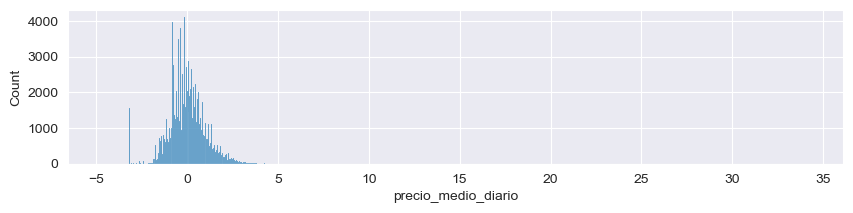

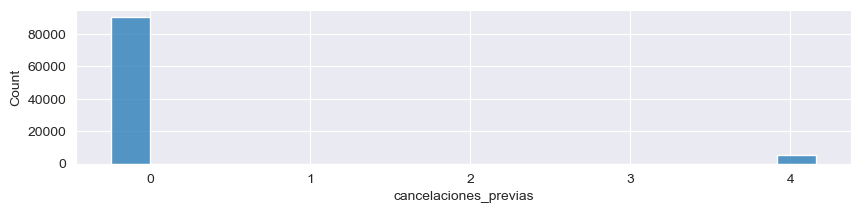

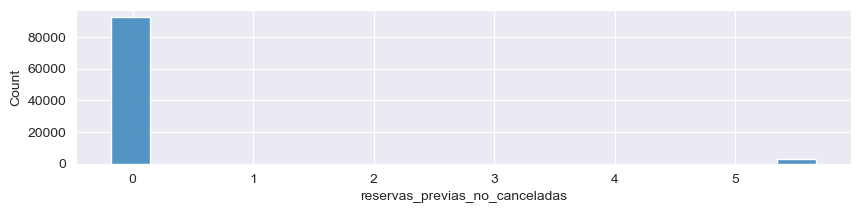

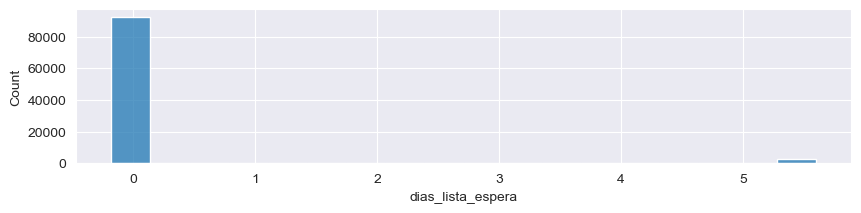

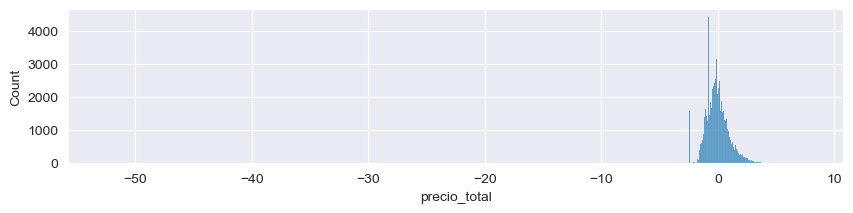

In [28]:
# Código del estudiante
for col in num_cols1:
    plt.figure(figsize=(10,2))
    sns.histplot(data=X_train, x=col)
    plt.show()



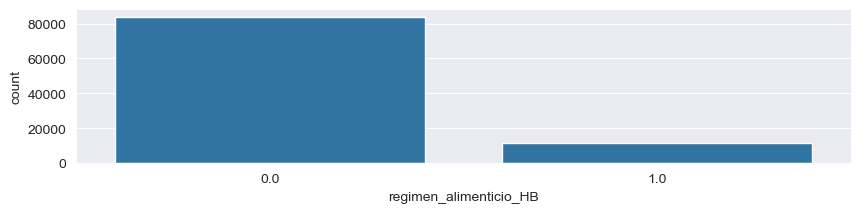

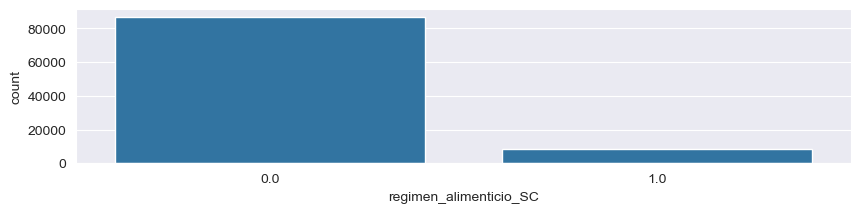

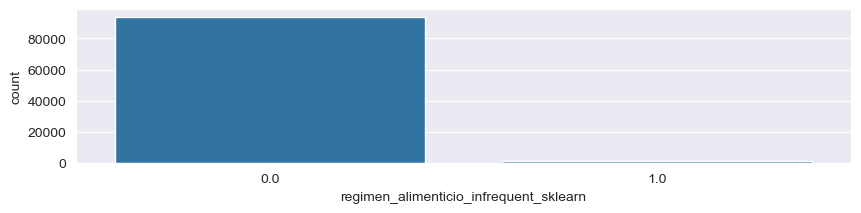

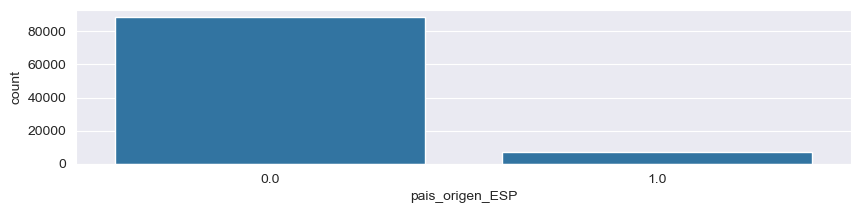

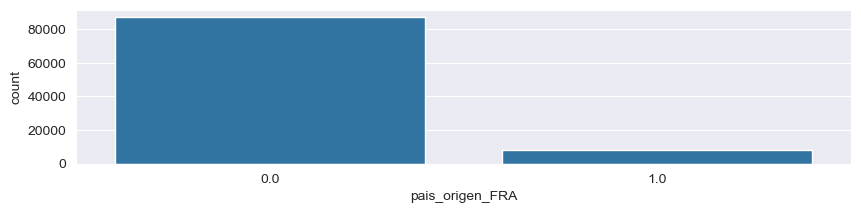

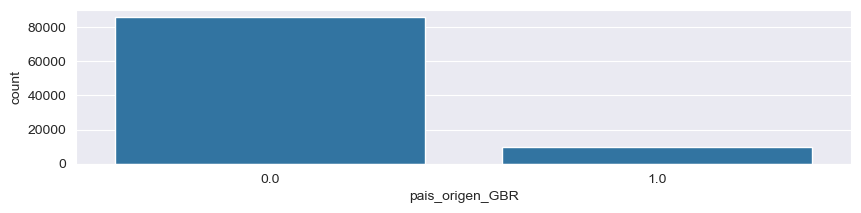

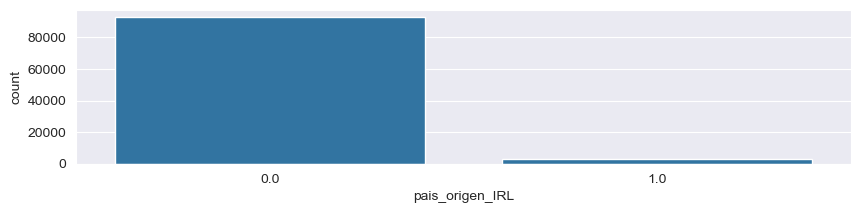

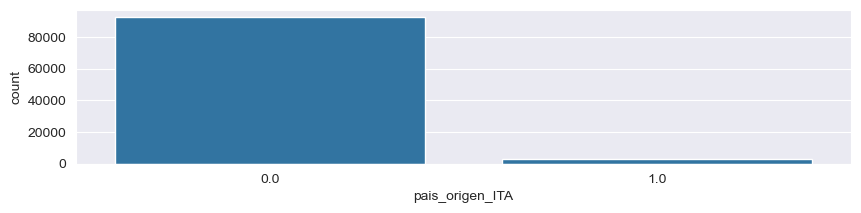

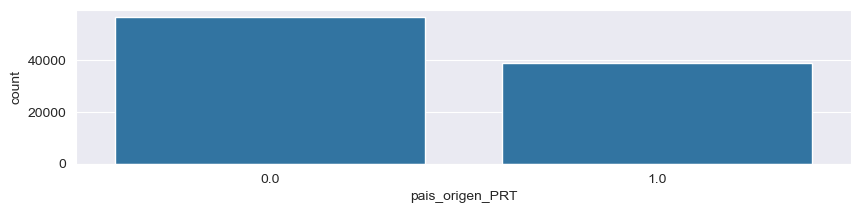

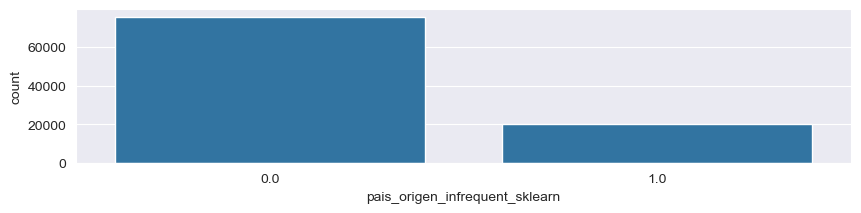

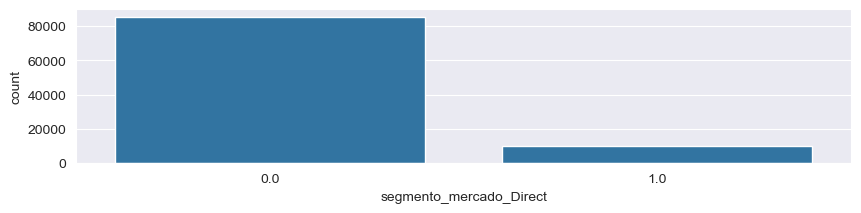

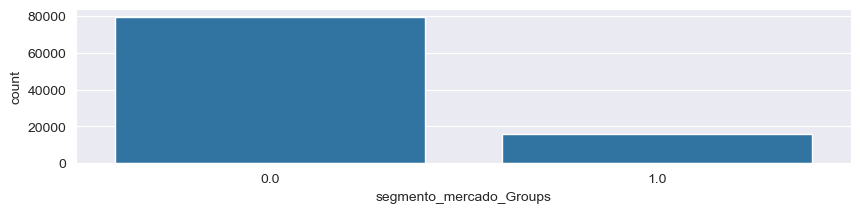

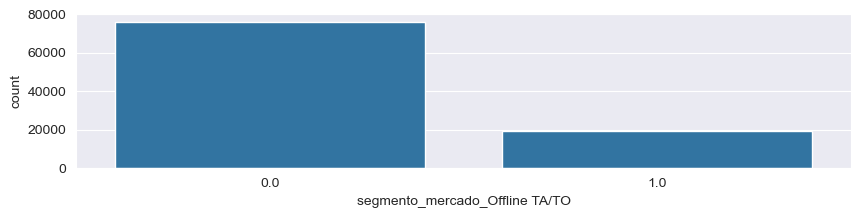

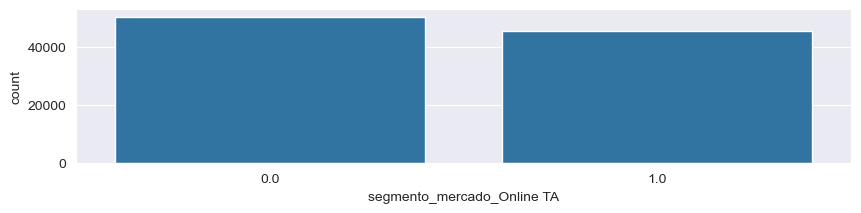

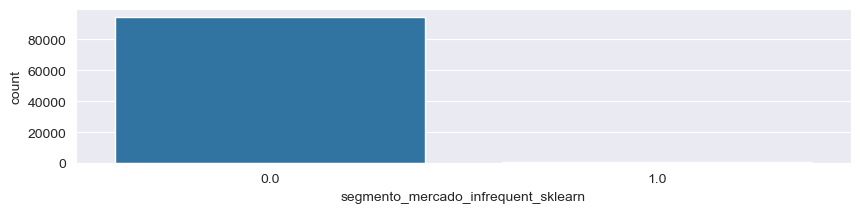

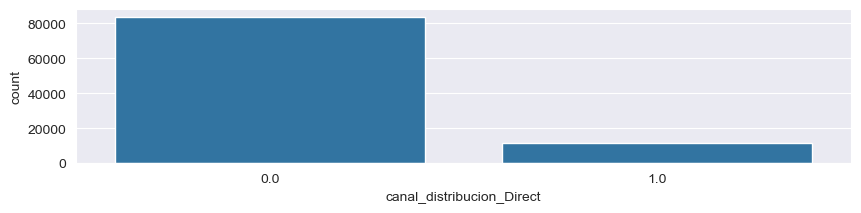

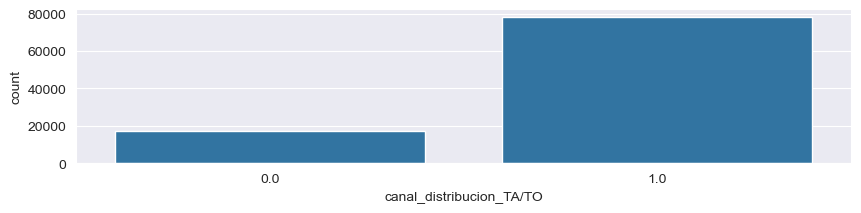

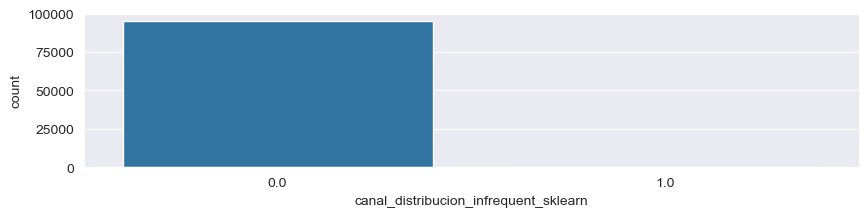

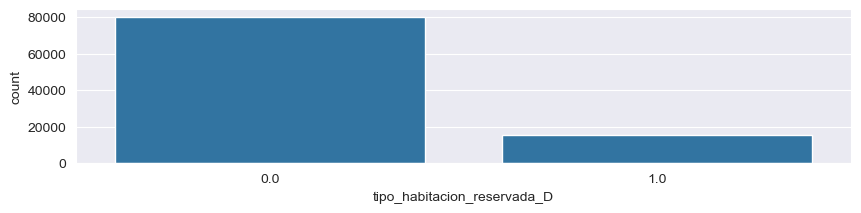

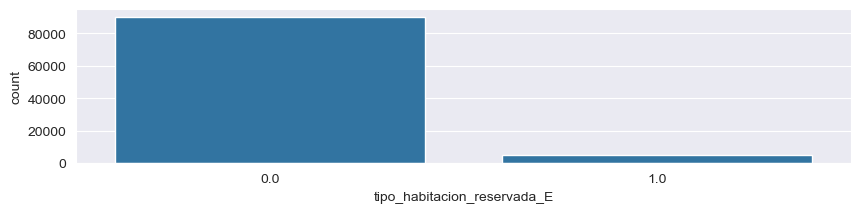

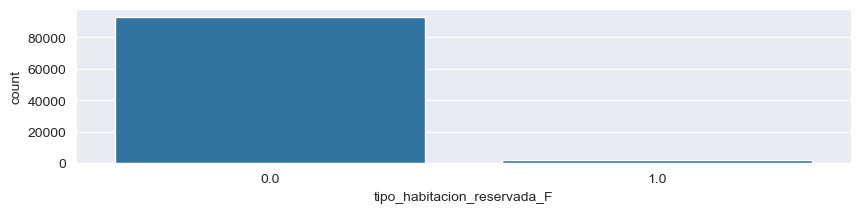

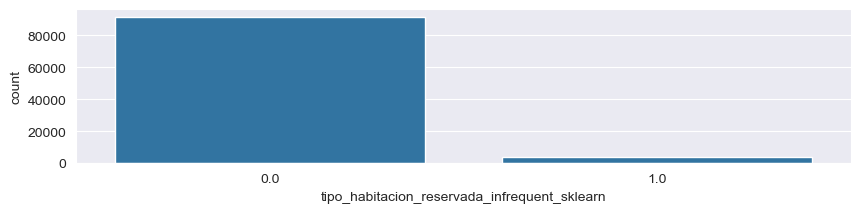

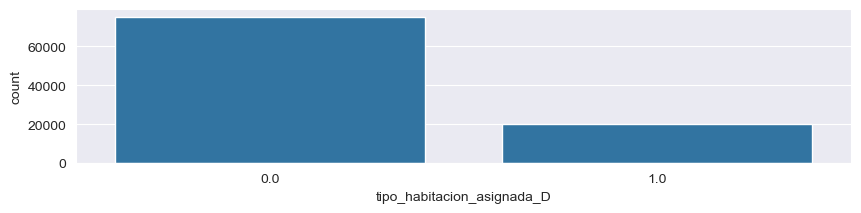

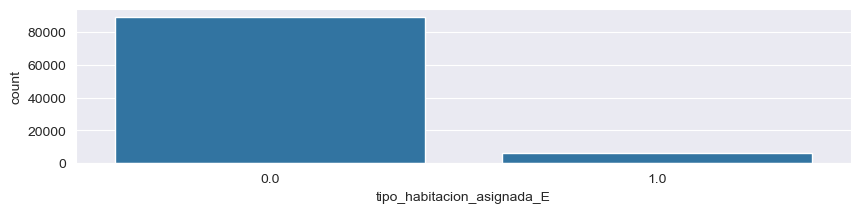

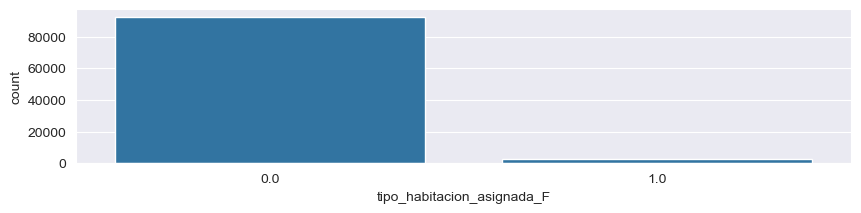

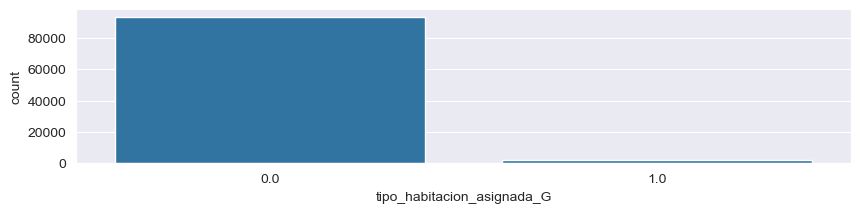

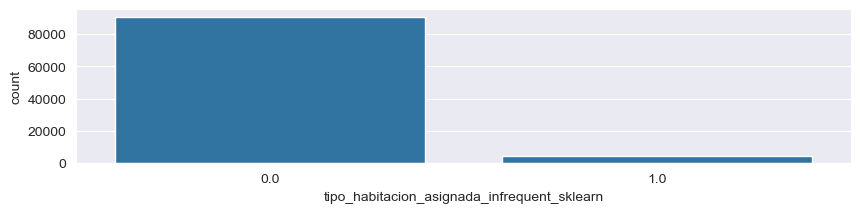

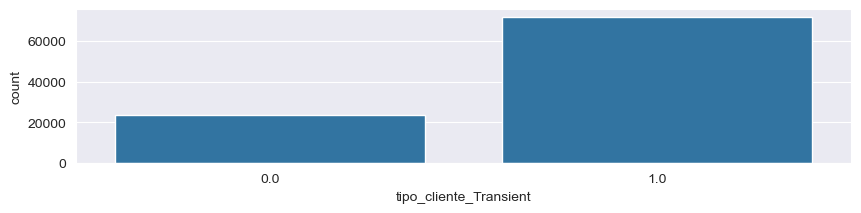

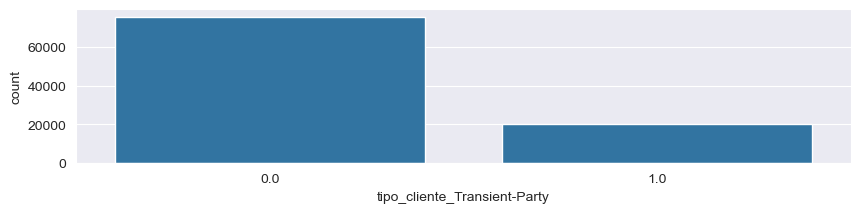

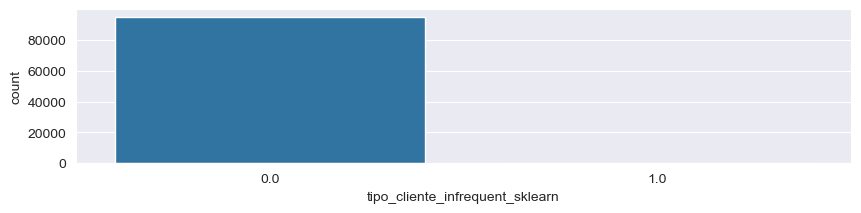

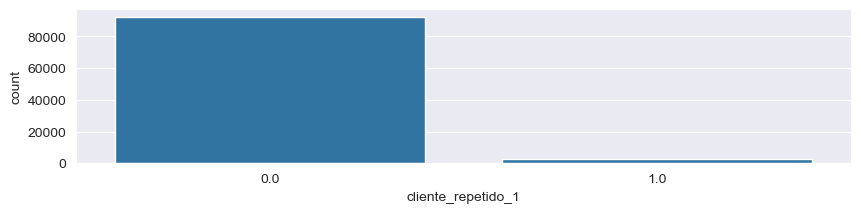

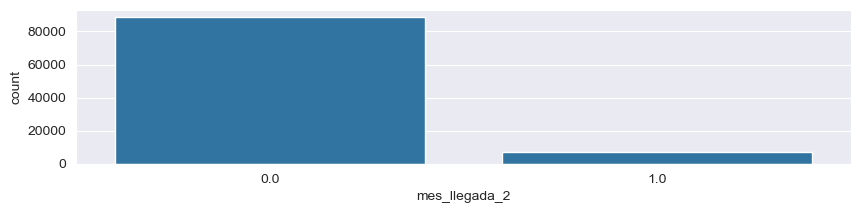

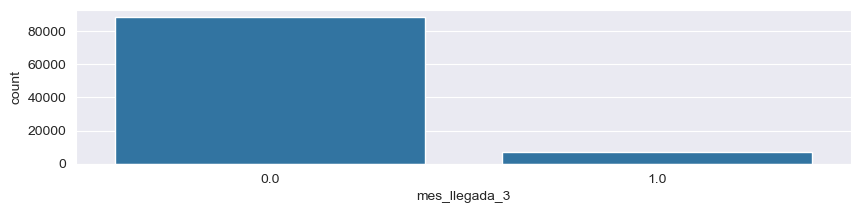

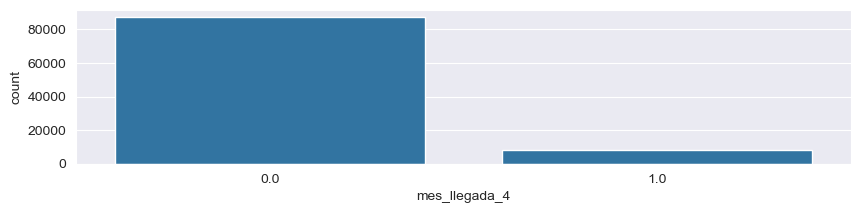

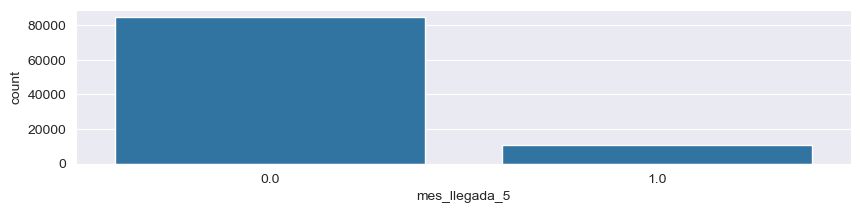

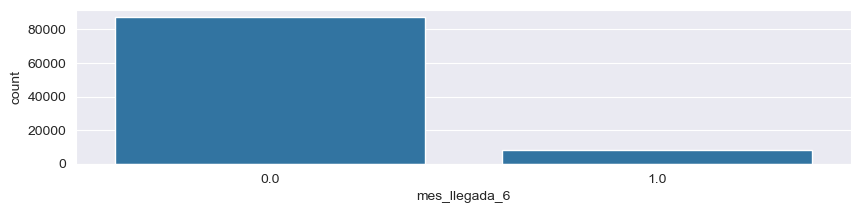

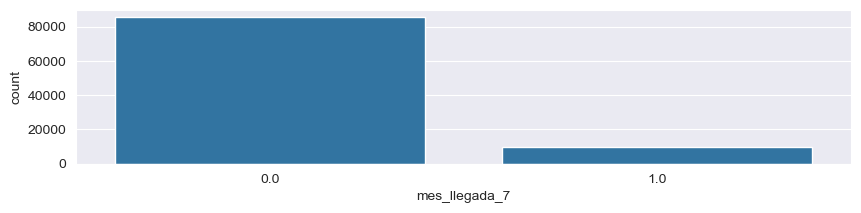

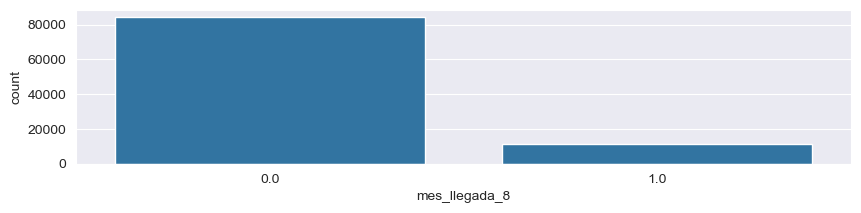

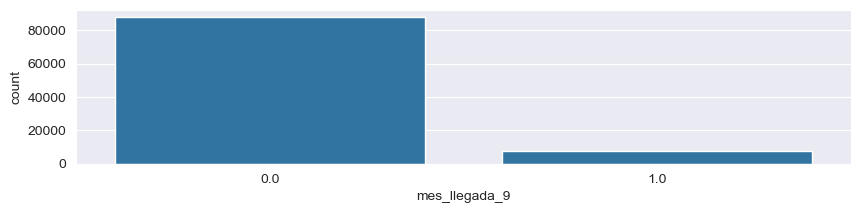

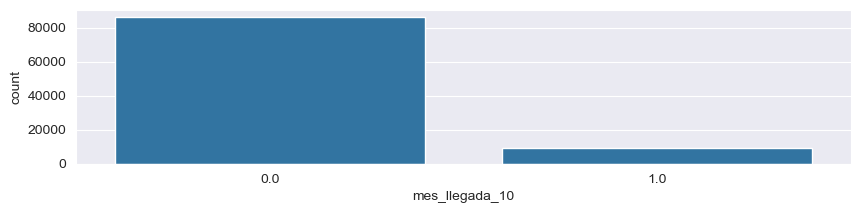

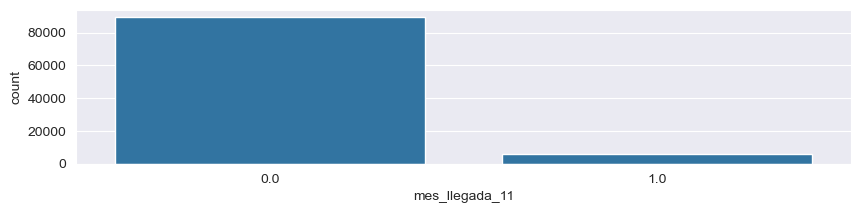

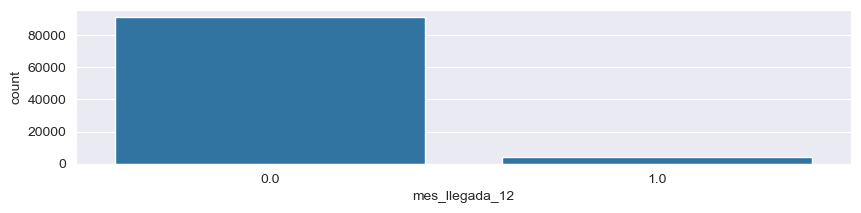

In [29]:
#Categórica

for col in new_cols:
    plt.figure(figsize=(10,2))
    sns.countplot(data=X_train, x=col)
    plt.show()

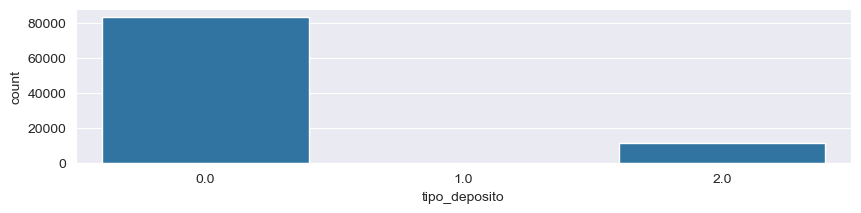

In [30]:
# Ordinales 
for col in ["tipo_deposito"]:
    plt.figure(figsize=(10, 2))
    sns.countplot(data=X_train, x=col)
    plt.show()

# Parte 2: Modelo Explicativo (3 puntos)

Dado que la muestra es tan grande. Podremos realizar perfectamente un modelo explicativo con el conjunto de train. No usaremos, por contra, el conjunto de test.

Así, se pedirá en este apartado realizar todo el análisis necesario exclusivamente con la librería de _statsmodels_ para ajustar un modelo explicativo de regresión logística. Para ello, es posible que tengáis que eliminar algunas features, modificar alguna existente, crear alguna nueva, trabajar outliers, plots, análisis, etc. 

Tenéis total libertad para elaborar el modelo explicativo con el conjunto de train según vuestro propio criterio. Todas las iteraciones y decisiones que toméis, estarán aquí reflejadas y comentadas por vuestra parte. Podéis crear todas las celdas que consideréis necesarias. 

In [31]:
# Código del estudiante

import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)

model = sm.Logit(y_train, X_train_sm)

resultado = model.fit()

print(resultado.summary())

         Current function value: 0.365497
         Iterations: 35


C:\Users\rebe_\anaconda3\envs\dataenv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                           Logit Regression Results                           
Dep. Variable:      reserva_cancelada   No. Observations:                95512
Model:                          Logit   Df Residuals:                    95453
Method:                           MLE   Df Model:                           58
Date:                Mon, 13 Jul 2026   Pseudo R-squ.:                  0.4463
Time:                        20:20:08   Log-Likelihood:                -34909.
converged:                      False   LL-Null:                       -63043.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
const                                           -2.8703      0.121    -23.664      0.000      -3.108      -2.633
dias_antelacion              

In [32]:
# Código del estudiante
  
cols_drop = ["total_personas", "precio_total"]  #posibles variables muy relacionadas

X_train = X_train.drop(columns=cols_drop)

In [33]:
# Código del estudiante

X_train_sm = sm.add_constant(X_train)

model = sm.Logit(y_train, X_train_sm)
resultado = model.fit()

print(resultado.summary())

         Current function value: 0.365497
         Iterations: 35


C:\Users\rebe_\anaconda3\envs\dataenv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                           Logit Regression Results                           
Dep. Variable:      reserva_cancelada   No. Observations:                95512
Model:                          Logit   Df Residuals:                    95454
Method:                           MLE   Df Model:                           57
Date:                Mon, 13 Jul 2026   Pseudo R-squ.:                  0.4463
Time:                        20:20:11   Log-Likelihood:                -34909.
converged:                      False   LL-Null:                       -63043.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
const                                           -2.8694      0.117    -24.588      0.000      -3.098      -2.641
dias_antelacion              

In [34]:
# Código del estudiante
X_train = X_train.drop(columns=["plazas_parking_requeridas"])


In [35]:
# Código del estudiante 

import statsmodels.api as sm

X_sm = sm.add_constant(X_train)

model = sm.Logit(y_train, X_sm)

resultado = model.fit()

print(resultado.summary())


Optimization terminated successfully.
         Current function value: 0.383673
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:      reserva_cancelada   No. Observations:                95512
Model:                          Logit   Df Residuals:                    95455
Method:                           MLE   Df Model:                           56
Date:                Mon, 13 Jul 2026   Pseudo R-squ.:                  0.4187
Time:                        20:20:12   Log-Likelihood:                -36645.
converged:                       True   LL-Null:                       -63043.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
const                                   

In [36]:
cols_eliminar = ["bebes", "es_familia", "segmento_mercado_Offline TA/TO", "tipo_cliente_infrequent_sklearn", 
                 "mes_llegada_2", "mes_llegada_3", "mes_llegada_12"]

X_train_final = X_train.drop(columns=cols_eliminar)


Modelo de referencia. En la última de vuestras celdas dejad claro cuál es el modelo final de referencia a continuación.

In [37]:
import statsmodels.api as sm

X_sm = sm.add_constant(X_train_final)

model = sm.Logit(y_train, X_sm)

resultado = model.fit()

print(resultado.summary())

Optimization terminated successfully.
         Current function value: 0.383733
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:      reserva_cancelada   No. Observations:                95512
Model:                          Logit   Df Residuals:                    95462
Method:                           MLE   Df Model:                           49
Date:                Mon, 13 Jul 2026   Pseudo R-squ.:                  0.4186
Time:                        20:20:13   Log-Likelihood:                -36651.
converged:                       True   LL-Null:                       -63043.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
const                                   

Para finalizar este apartado, tendréis que aportar un resumen de las conclusiones de vuestro estudio. Se permite un máximo de 5 bullets.

In [38]:
# Comentarios del estudiante

#Conclusiones del análisis

#1. La variable más influyente en la cancelación es el tipo de depósito.
   #El modelo muestra que el tipo de depósito tiene un efecto muy significativo sobre la probabilidad de cancelación. 

#2. La antelación de la reserva es un factor clave.
   #Se observa una relación positiva entre los días de antelación y la cancelación. 

#3. El historial del cliente influye en el comportamiento de cancelación.
   #Los clientes que anteriormente han realizado cancelaciones presentan una mayor probabilidad de volver a cancelar
   

#4. Las características de la reserva y del alojamiento afectan a la cancelación.
   #Variables como el tipo de habitación reservada, el tipo de habitación asignada, 
    #el precio medio diario o el canal de distribución presentan una influencia significativa sobre la probabilidad de cancelación

#5. El modelo explicativo obtenido es adecuado y estadísticamente significativo.
   #Tras aplicar las transformaciones necesarias se obtuvo un modelo de regresión logística que presentó un buen ajuste. 
   #Además, la eliminación de variables no significativas permitió obtener un modelo más sencillo manteniendo prácticamente el mismo poder explicativo.


# Parte 3: Modelo Predictivo (4 puntos)

Aquí realizaremos un modelo predictivo que entrenaremos con el conjunto de train. Así, se pedirá en este apartado realizar todo el trabajo necesario exclusivamente con la librería de _sklearn_ para ajustar un modelo predictivo de regresión logística. Para ello, es posible que tengáis que eliminar algunas features, modificar alguna existente, crear alguna nueva, trabajar outliers, plots, análisis, etc.

Finalmente, se pedirá utilizar el conjunto de test para evaluar la métrica del modelo. Se medirá el accuracy **exclusivamente sobre el conjunto de test**. Pero tenéis total libertad para estudiar si se puede mejorar el umbral de probabilidad de la regresión lineal. 

In [39]:
# Código del estudiante
X_test_final = X_test.drop(columns=cols_eliminar)
X_test_final = X_test_final.reindex(columns=X_train_final.columns, fill_value=0)

In [40]:
# Código del estudiante

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)

model.fit(X_train_final, y_train)

y_pred = model.predict(X_test_final)

acc = accuracy_score(y_test, y_pred)

print(f"Final accuracy={acc:.3f}")



Final accuracy=0.815


In [41]:
#  El modelo predictivo basado en regresión logística obtiene una accuracy del 81,5% sobre el conjunto de test,
# mostrando una capacidad adecuada para clasificar las reservas según su probabilidad de cancelación

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_val_score(
    model,
    X_train_final,
    y_train,
    cv=cv,
    scoring='accuracy'
)

print(scores)
print("Accuracy media:", scores.mean())

In [ ]:
coef = pd.DataFrame({
    "variable": X_train_final.columns,
    "coeficiente": model.coef_[0]
})

coef.sort_values(
    by="coeficiente",
    ascending=False)

In [ ]:
# Interpretación de coeficientes:

# Principales factores que aumentan la cancelación:
# pais_origen_PRT y tipo_deposito son las variables con mayor impacto positivo
# Las reservas realizadas mediante Online TA presentan mayor riesgo de cancelación
# Un mayor número de cancelaciones previas y más días de antelación aumentan la probabilidad de cancelar

# Principales factores que reducen la cancelación:
# Los clientes repetidores y aquellos con reservas previas no canceladas muestran menor riesgo
# Tener peticiones especiales y reservar mediante canal directo disminuye la probabilidad de cancelación
# Algunas categorías de habitación asignada presentan un efecto negativo importante.

# Conclusión:
# El modelo identifica que el historial del cliente, el tipo de depósito, el canal de reserva,
# el origen del cliente y las características de la habitación son los factores más relevantes
# para predecir la cancelación de reservas.

In [ ]:
#El modelo predictivo basado en regresión logística obtiene una accuracy del 82%, 
#mostrando un buen rendimiento general en la clasificación de reservas canceladas y no canceladas. 
#El modelo presenta una mayor capacidad para identificar reservas que finalmente no son canceladas, alcanzando un recall del 90% para esta clase. 
#En el caso de las cancelaciones, obtiene una precisión del 80%, aunque el recall disminuye hasta el 66%, 
#indicando que existe un porcentaje de cancelaciones reales que el modelo no consigue detectar. 
#En conjunto, los resultados muestran que el modelo tiene una capacidad predictiva adecuada, 
#aunque podría mejorarse mediante técnicas de ajuste del umbral de decisión, balanceo de clases o modelos más complejos.